In [219]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [220]:
from google.colab import files
uploaded = files.upload()

Saving Egy-COVID-19.csv to Egy-COVID-19 (8).csv


In [221]:
df = pd.read_csv("Egy-COVID-19.csv")
df.head(10)


,date,new_confirmed,new_deaths,new_recovered,new_pos_to_neg,active_pos,cases_in_hospital,total_confirmed,total_deaths,total_recovered,total_pos_to_neg,lockdown,lockdown_duration
0,3/1/2020,1,0,0,0,1,1,2,0,1,1,No,0
1,3/2/2020,0,0,0,0,1,1,2,0,1,1,No,0
2,3/3/2020,0,0,0,0,1,1,2,0,1,1,No,0
3,3/4/2020,0,0,0,0,1,1,2,0,1,1,No,0
4,3/5/2020,1,0,0,0,2,2,3,0,1,1,No,0
5,3/6/2020,12,0,0,0,14,14,15,0,1,1,No,0
6,3/7/2020,33,0,0,0,47,47,48,0,1,1,No,0
7,3/8/2020,7,1,0,0,54,54,55,1,1,1,No,0
8,3/9/2020,4,0,0,20,38,58,59,1,1,21,No,0
9,3/10/2020,1,0,0,5,34,59,60,1,1,26,No,0


In [222]:
#check data size
df.shape

(85, 13)

In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               85 non-null     object
 1   new_confirmed      85 non-null     int64 
 2   new_deaths         85 non-null     int64 
 3   new_recovered      85 non-null     int64 
 4   new_pos_to_neg     85 non-null     int64 
 5   active_pos         85 non-null     int64 
 6   cases_in_hospital  85 non-null     int64 
 7   total_confirmed    85 non-null     int64 
 8   total_deaths       85 non-null     int64 
 9   total_recovered    85 non-null     int64 
 10  total_pos_to_neg   85 non-null     int64 
 11  lockdown           85 non-null     object
 12  lockdown_duration  85 non-null     int64 
dtypes: int64(11), object(2)
memory usage: 8.8+ KB


In [186]:
df.replace('?', np.nan, inplace=True)

In [187]:
## Convert the 'date' from object to datetime format
df['date']=pd.to_datetime(df['date'])

In [188]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [189]:
#check if lockdown_duration > 0 then lockdown 'YES' else 'NO'
df['lockdown'] = np.where(df['lockdown_duration'] > 0, 'Yes', 'No')

In [190]:
#add new column to calculate death rate
df['deathrate']=(df['total_deaths']/df['total_confirmed'])*100

In [191]:
#round to two decimal places
df['deathrate'] = df['deathrate'].round(2)

In [192]:
# Save the cleaned data to a new CSV file
df.to_csv('Egy-COVID-19_Cleaned.csv', index=False)

In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               85 non-null     datetime64[ns]
 1   new_confirmed      85 non-null     int64         
 2   new_deaths         85 non-null     int64         
 3   new_recovered      85 non-null     int64         
 4   new_pos_to_neg     85 non-null     int64         
 5   active_pos         85 non-null     int64         
 6   cases_in_hospital  85 non-null     int64         
 7   total_confirmed    85 non-null     int64         
 8   total_deaths       85 non-null     int64         
 9   total_recovered    85 non-null     int64         
 10  total_pos_to_neg   85 non-null     int64         
 11  lockdown           85 non-null     object        
 12  lockdown_duration  85 non-null     int64         
 13  deathrate          85 non-null     float64       
dtypes: datetime6

In [194]:
df.head()

,date,new_confirmed,new_deaths,new_recovered,new_pos_to_neg,active_pos,cases_in_hospital,total_confirmed,total_deaths,total_recovered,total_pos_to_neg,lockdown,lockdown_duration,deathrate
0,2020-03-01,1,0,0,0,1,1,2,0,1,1,No,0,0.0
1,2020-03-02,0,0,0,0,1,1,2,0,1,1,No,0,0.0
2,2020-03-03,0,0,0,0,1,1,2,0,1,1,No,0,0.0
3,2020-03-04,0,0,0,0,1,1,2,0,1,1,No,0,0.0
4,2020-03-05,1,0,0,0,2,2,3,0,1,1,No,0,0.0


In [195]:
#count the missing data
df.isnull().sum()


,0
date,0
new_confirmed,0
new_deaths,0
new_recovered,0
new_pos_to_neg,0
active_pos,0
cases_in_hospital,0
total_confirmed,0
total_deaths,0
total_recovered,0


Explore categorical data

In [196]:
categorical = [var for var in df.columns if df[var].dtype=='O']
print('There are {} categorical variables\n'.format(len(categorical)))
print('The categorical variables are :\n\n', categorical)

There are 1 categorical variables

The categorical variables are :

 ['lockdown']


In [197]:
df[categorical].head()

,lockdown
0,No
1,No
2,No
3,No
4,No


Check missing values

In [224]:

df[categorical].isnull().sum()

,0
lockdown,0


 View frequency counts of values in the only categorical variable

In [225]:


for var in categorical:
    print('**************************')
    print(var)
    print('---------------------------')
    print(df[var].value_counts())

**************************
lockdown
---------------------------
lockdown
Yes    61
No     24
Name: count, dtype: int64


since our categorical data type is nominal we can encode it using One Hot Encoder

In [201]:
from sklearn.preprocessing import OneHotEncoder
df = pd.get_dummies(df, columns=['lockdown'], drop_first=True)
df['lockdown_Yes'] = df['lockdown_Yes'].astype(int)
df['lockdown_Yes'].head()

,lockdown_Yes
0,0
1,0
2,0
3,0
4,0


Explore numerical data

In [202]:
numerical = [var for var in df.columns if df[var].dtype!='O']
print('There are {} numerical variables\n'.format(len(numerical)))
print('The numerical variables are :', numerical)

There are 14 numerical variables

The numerical variables are : ['date', 'new_confirmed', 'new_deaths', 'new_recovered', 'new_pos_to_neg', 'active_pos', 'cases_in_hospital', 'total_confirmed', 'total_deaths', 'total_recovered', 'total_pos_to_neg', 'lockdown_duration', 'deathrate', 'lockdown_Yes']


we notcied that lockdown is a numerical variable as a result of the encoding

In [203]:
df[numerical].head()

,date,new_confirmed,new_deaths,new_recovered,new_pos_to_neg,active_pos,cases_in_hospital,total_confirmed,total_deaths,total_recovered,total_pos_to_neg,lockdown_duration,deathrate,lockdown_Yes
0,2020-03-01,1,0,0,0,1,1,2,0,1,1,0,0.0,0
1,2020-03-02,0,0,0,0,1,1,2,0,1,1,0,0.0,0
2,2020-03-03,0,0,0,0,1,1,2,0,1,1,0,0.0,0
3,2020-03-04,0,0,0,0,1,1,2,0,1,1,0,0.0,0
4,2020-03-05,1,0,0,0,2,2,3,0,1,1,0,0.0,0


In [204]:
df[numerical].isnull().sum()

,0
date,0
new_confirmed,0
new_deaths,0
new_recovered,0
new_pos_to_neg,0
active_pos,0
cases_in_hospital,0
total_confirmed,0
total_deaths,0
total_recovered,0


show statistics for numerical values excluding date and lockdown

In [205]:
df[['new_confirmed', 'new_deaths', 'new_recovered', 'new_pos_to_neg',
    'active_pos', 'cases_in_hospital', 'total_confirmed', 'total_deaths',
    'total_recovered', 'total_pos_to_neg', 'lockdown_duration', 'deathrate']].describe()

,new_confirmed,new_deaths,new_recovered,new_pos_to_neg,active_pos,cases_in_hospital,total_confirmed,total_deaths,total_recovered,total_pos_to_neg,lockdown_duration,deathrate
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,203.105882,8.988235,56.541176,63.117647,2832.305882,3061.188235,4081.705882,234.305882,1020.517647,1249.400000,7.023529,5.099765
std,211.650207,7.313546,70.724575,72.380018,3277.805171,3477.528540,4731.883215,238.578929,1262.462839,1459.168258,4.498615,2.318635
min,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,36.000000,2.000000,7.000000,10.000000,253.000000,271.000000,327.000000,14.000000,56.000000,74.000000,0.000000,4.280000
50%,139.000000,9.000000,31.000000,37.000000,1476.000000,1618.000000,2065.000000,159.000000,447.000000,589.000000,9.000000,5.730000
75%,338.000000,14.000000,70.000000,89.000000,4424.000000,4903.000000,6465.000000,429.000000,1562.000000,2041.000000,10.000000,6.950000
max,783.000000,29.000000,302.000000,309.000000,11899.000000,12458.000000,17265.000000,764.000000,4807.000000,5366.000000,13.000000,7.700000


Show the outliers along with the upper/lower bounds for each numerical variable

In [206]:
def out_iqr(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1
    cut_off = iqr * 1.5

    lower = q1 - cut_off
    upper = q3 + cut_off

    print('---------------------------')
    print(f'Column: {column}')
    print(f'The IQR is: {iqr}')
    print(f'The lower bound is: {lower}')
    print(f'The upper bound is: {upper}')

    # Calculate the number of outliers
    outliers = df[(df[column] > upper) | (df[column] < lower)]
    print(f'Total number of outliers: {outliers.shape[0]}')

---------------------------
Column: new_confirmed
The IQR is: 302.0
The lower bound is: -417.0
The upper bound is: 791.0
Total number of outliers: 0


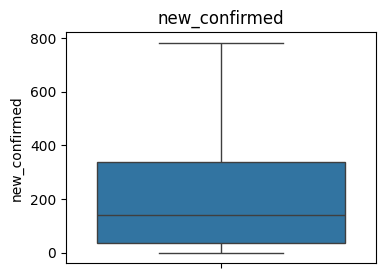

---------------------------
Column: new_deaths
The IQR is: 12.0
The lower bound is: -16.0
The upper bound is: 32.0
Total number of outliers: 0


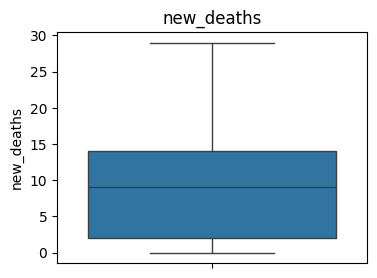

---------------------------
Column: new_recovered
The IQR is: 63.0
The lower bound is: -87.5
The upper bound is: 164.5
Total number of outliers: 8


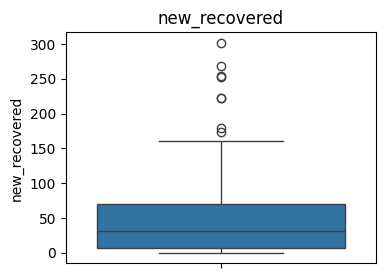

---------------------------
Column: new_pos_to_neg
The IQR is: 79.0
The lower bound is: -108.5
The upper bound is: 207.5
Total number of outliers: 7


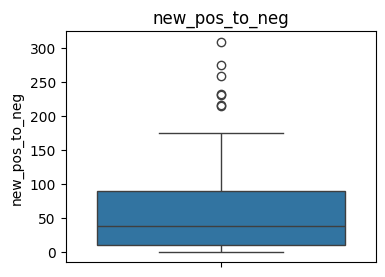

---------------------------
Column: active_pos
The IQR is: 4171.0
The lower bound is: -6003.5
The upper bound is: 10680.5
Total number of outliers: 3


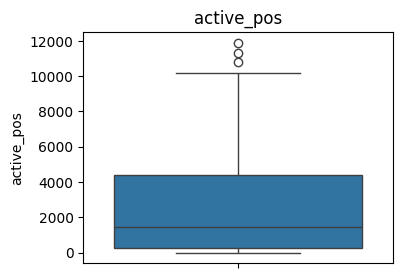

---------------------------
Column: cases_in_hospital
The IQR is: 4632.0
The lower bound is: -6677.0
The upper bound is: 11851.0
Total number of outliers: 2


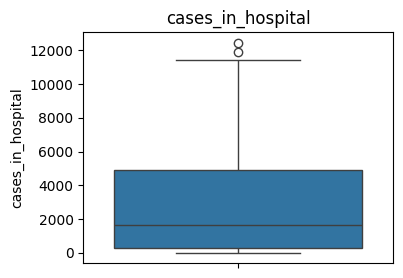

---------------------------
Column: total_confirmed
The IQR is: 6138.0
The lower bound is: -8880.0
The upper bound is: 15672.0
Total number of outliers: 3


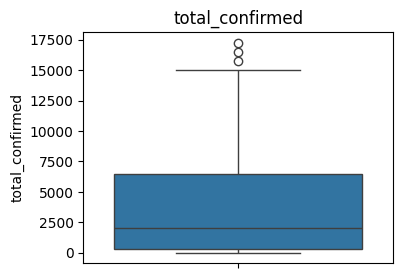

---------------------------
Column: total_deaths
The IQR is: 415.0
The lower bound is: -608.5
The upper bound is: 1051.5
Total number of outliers: 0


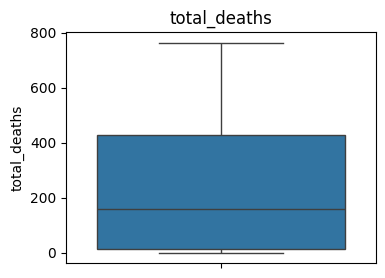

---------------------------
Column: total_recovered
The IQR is: 1506.0
The lower bound is: -2203.0
The upper bound is: 3821.0
Total number of outliers: 5


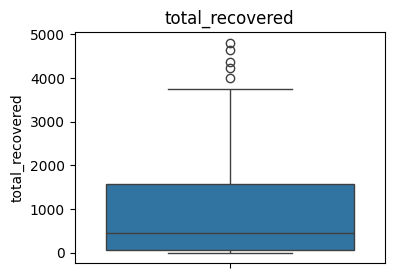

---------------------------
Column: total_pos_to_neg
The IQR is: 1967.0
The lower bound is: -2876.5
The upper bound is: 4991.5
Total number of outliers: 2


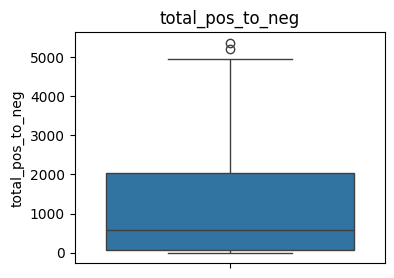

---------------------------
Column: lockdown_duration
The IQR is: 10.0
The lower bound is: -15.0
The upper bound is: 25.0
Total number of outliers: 0


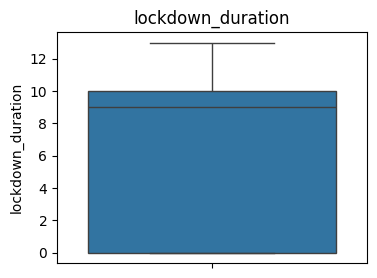

---------------------------
Column: deathrate
The IQR is: 2.67
The lower bound is: 0.27500000000000036
The upper bound is: 10.955
Total number of outliers: 7


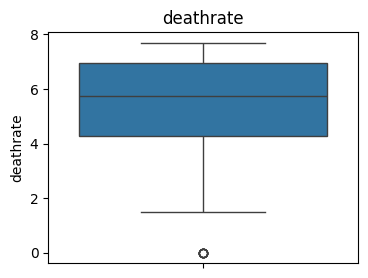

In [211]:
# Plotting
numerical = ['new_confirmed', 'new_deaths', 'new_recovered', 'new_pos_to_neg',
    'active_pos', 'cases_in_hospital', 'total_confirmed', 'total_deaths',
    'total_recovered', 'total_pos_to_neg', 'lockdown_duration', 'deathrate']

for n in numerical:
    out_iqr(df, n)
    plt.figure(figsize=(4, 3)) # Added to make plots look cleaner
    sns.boxplot(y=df[n]) # Changed to Seaborn for better looking boxes
    plt.title(n)
    plt.show()

because our dataset is small with size 85, triming delete outlier rows entirely and COVID spikes are real events, not errors we use capping to handle the outliers

In [212]:
for n in numerical:
    iqr = df[n].quantile(0.75) - df[n].quantile(0.25)
    lower_bound = df[n].quantile(0.25)-1.5*iqr
    upper_bound = df[n].quantile(0.75)+1.5*iqr
    df[n] = np.where(df[n]>upper_bound,df[n].quantile(0.9), np.where(df[n]<lower_bound,df[n].quantile(0.1),df[n]))

check if all the outliers are removed

---------------------------
Column: new_confirmed
The IQR is: 302.0
The lower bound is: -417.0
The upper bound is: 791.0
Total number of outliers: 0


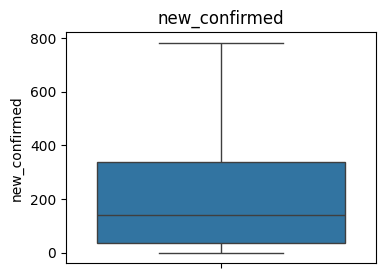

---------------------------
Column: new_deaths
The IQR is: 12.0
The lower bound is: -16.0
The upper bound is: 32.0
Total number of outliers: 0


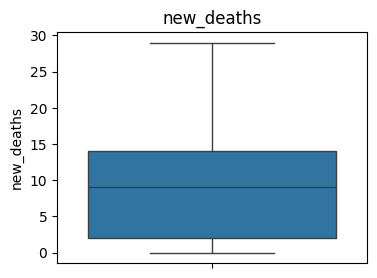

---------------------------
Column: new_recovered
The IQR is: 63.0
The lower bound is: -87.5
The upper bound is: 164.5
Total number of outliers: 0


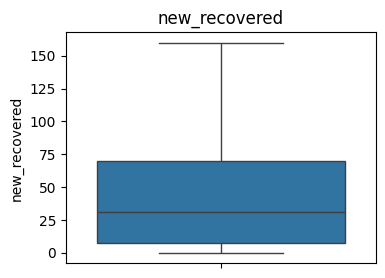

---------------------------
Column: new_pos_to_neg
The IQR is: 79.0
The lower bound is: -108.5
The upper bound is: 207.5
Total number of outliers: 0


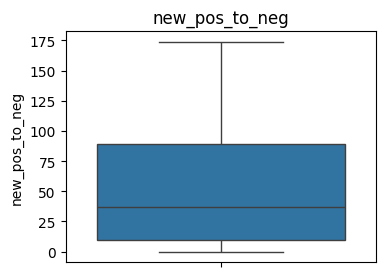

---------------------------
Column: active_pos
The IQR is: 4171.0
The lower bound is: -6003.5
The upper bound is: 10680.5
Total number of outliers: 0


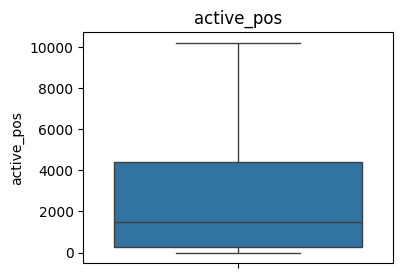

---------------------------
Column: cases_in_hospital
The IQR is: 4632.0
The lower bound is: -6677.0
The upper bound is: 11851.0
Total number of outliers: 0


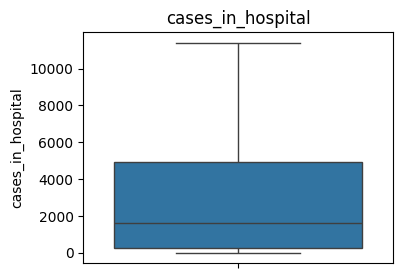

---------------------------
Column: total_confirmed
The IQR is: 6138.0
The lower bound is: -8880.0
The upper bound is: 15672.0
Total number of outliers: 0


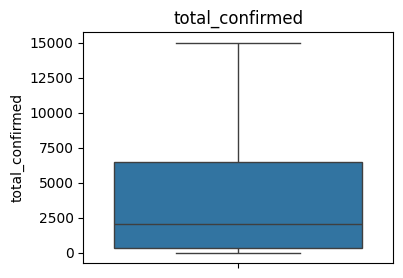

---------------------------
Column: total_deaths
The IQR is: 415.0
The lower bound is: -608.5
The upper bound is: 1051.5
Total number of outliers: 0


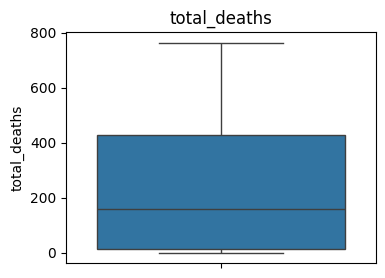

---------------------------
Column: total_recovered
The IQR is: 1506.0
The lower bound is: -2203.0
The upper bound is: 3821.0
Total number of outliers: 0


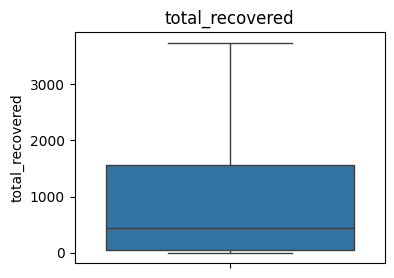

---------------------------
Column: total_pos_to_neg
The IQR is: 1967.0
The lower bound is: -2876.5
The upper bound is: 4991.5
Total number of outliers: 0


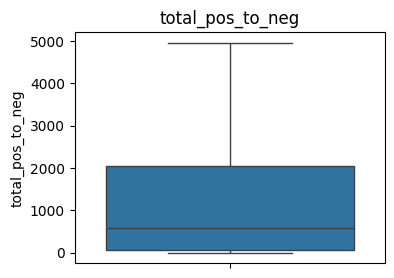

---------------------------
Column: lockdown_duration
The IQR is: 10.0
The lower bound is: -15.0
The upper bound is: 25.0
Total number of outliers: 0


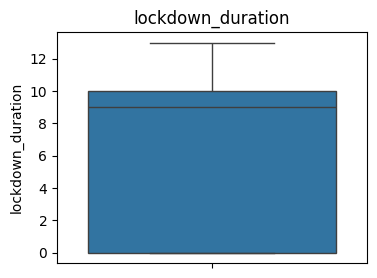

---------------------------
Column: deathrate
The IQR is: 2.67
The lower bound is: 0.27500000000000036
The upper bound is: 10.955
Total number of outliers: 0


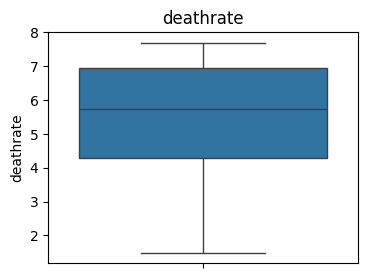

In [213]:
for n in numerical:
    out_iqr(df, n)
    plt.figure(figsize=(4, 3)) # Added to make plots look cleaner
    sns.boxplot(y=df[n]) # Changed to Seaborn for better looking boxes
    plt.title(n)
    plt.show()

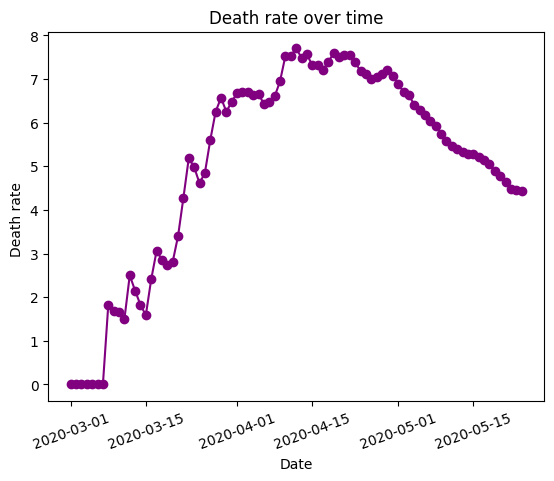

In [14]:

plt.plot(df['date'], df['deathrate'], color='purple', marker='o', linestyle='-')
plt.title('Death rate over time')
plt.xlabel('Date')
plt.ylabel('Death rate ')
plt.xticks(rotation=20)
plt.show()

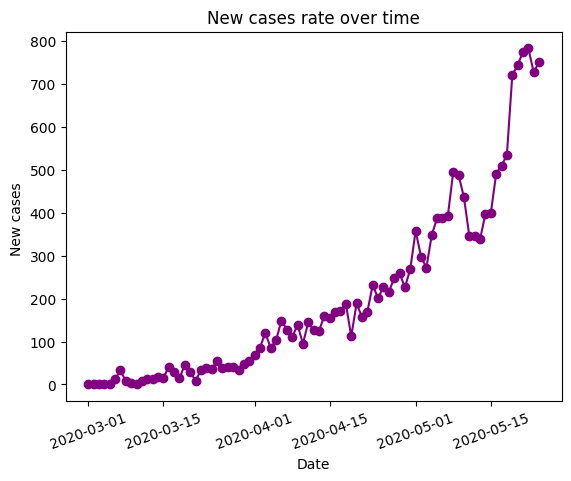

In [15]:
plt.plot(df['date'], df['new_confirmed'], color='purple', marker='o', linestyle='-')
plt.title('New cases rate over time')
plt.xlabel('Date')
plt.ylabel('New cases ')
plt.xticks(rotation=20)
plt.show()

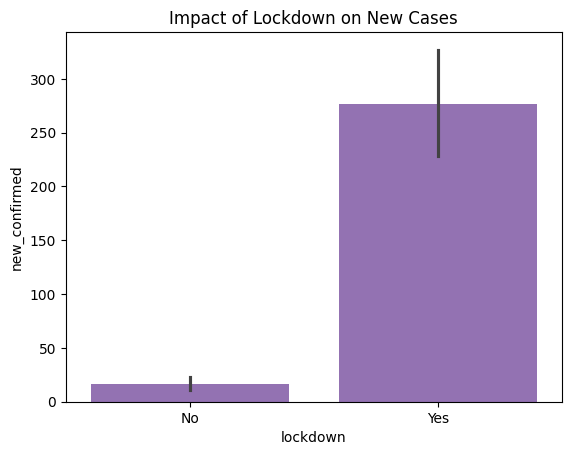

In [16]:
sns.color_palette()
base_color = sns.color_palette()[4]
sns.barplot(data=df,x='lockdown', y='new_confirmed', color=base_color)
plt.title('Impact of Lockdown on New Cases')
plt.show()

/tmp/ipykernel_3731/198131093.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lockdowndata,nolockdowndata], labels=['lockdown', 'no lockdown'])


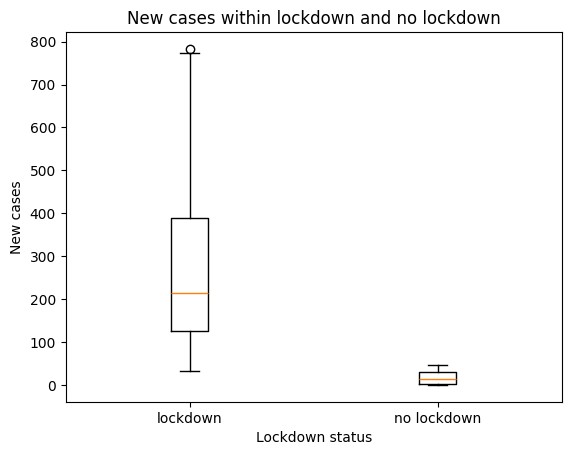

In [17]:

lockdowndata=df[df['lockdown'] == 'Yes']['new_confirmed']
nolockdowndata=df[df['lockdown'] == 'No']['new_confirmed']
plt.boxplot([lockdowndata,nolockdowndata], labels=['lockdown', 'no lockdown'])
plt.title('New cases within lockdown and no lockdown')
plt.xlabel('Lockdown status')
plt.ylabel('New cases')

plt.show()

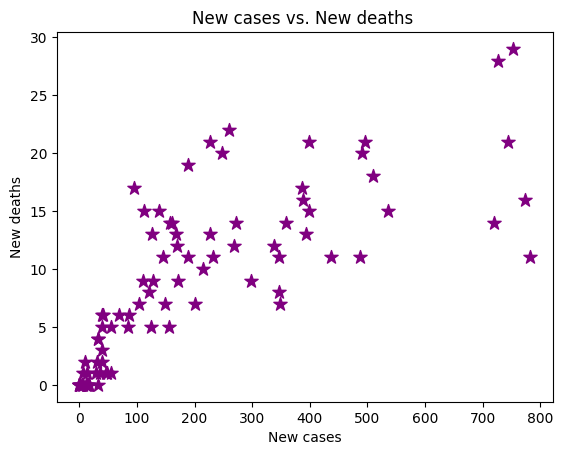

In [18]:
plt.scatter(df['new_confirmed'],df['new_deaths'], color='purple', s=100, marker='*')

plt.title('New cases vs. New deaths ')
plt.xlabel('New cases')
plt.ylabel('New deaths')

plt.show()

construct a heatmap to show the corrs and identify which ones most likely have a regression

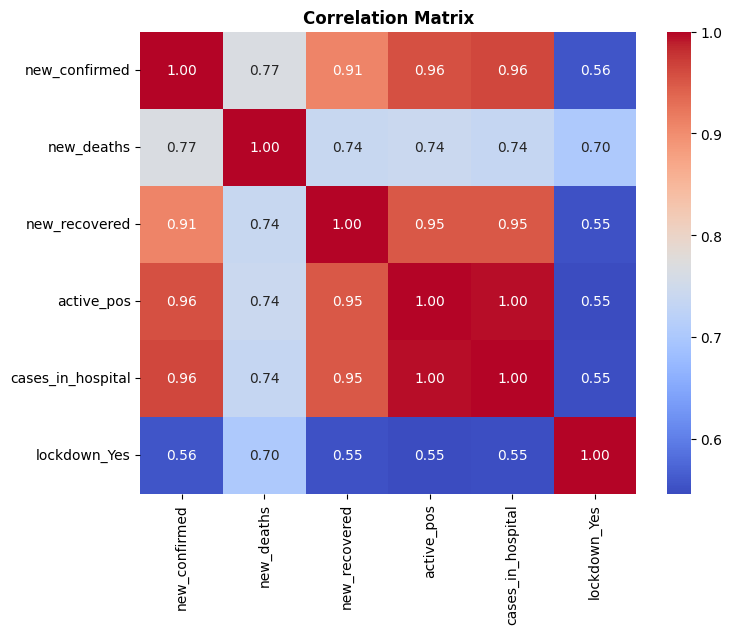

In [214]:
cols = ['new_confirmed', 'new_deaths', 'new_recovered',
        'active_pos', 'cases_in_hospital', 'lockdown_Yes']

corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix', fontweight='bold')
plt.show()

it's clear that new_confirmed & new_recovered have very strong +ve corr = 0.91
and new_confirmed & new_deaths too equals 0.77 which supports our H1

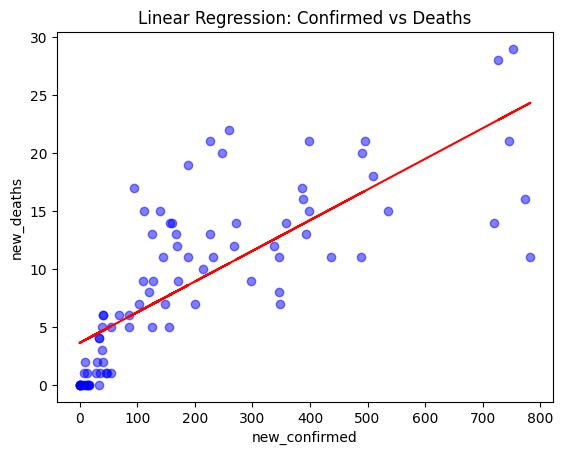

R² Score: 0.59


In [215]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = df[['new_confirmed']]
y = df['new_deaths']

model = LinearRegression()
model.fit(X, y)

plt.scatter(X, y, color='blue', alpha=0.5)
plt.plot(X, model.predict(X), color='red')
plt.xlabel('new_confirmed')
plt.ylabel('new_deaths')
plt.title('Linear Regression: Confirmed vs Deaths')
plt.show()

print(f"R² Score: {model.score(X, y):.2f}")

First Hypothesis Test:

H₀: There is no significant difference in new confirmed cases during lockdown vs
non-lockdown periods.

H₁: New confirmed cases are significantly lower during lockdown periods.

since im comparing new_confirmed which is numerical between two groups with a small sample size apply t-test

In [216]:
from scipy import stats

# H1 - t-test

lockdown_yes = df[df['lockdown_Yes'] == 1]['new_confirmed']
lockdown_no = df[df['lockdown_Yes'] == 0]['new_confirmed']

t_stat, p_value = stats.ttest_ind(lockdown_yes, lockdown_no)
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Reject H₀ - significant difference exists")
else:
    print("Fail to reject H₀ - no significant difference")

T-statistic: 6.089284228789215
P-value: 3.382821785409008e-08
Reject H₀ - significant difference exists


Second Hypothesis Test:

H₀: There is no significant correlation between daily new confirmed cases and daily new
deaths.


H₁: There is a significant positive correlation between new confirmed cases and new
deaths.

since im examinning the correlation between two numerical values apply pearson

In [217]:
# H2 - Pearson
corr, p_value = stats.pearsonr(df['new_confirmed'], df['new_deaths'])
print(f"Correlation: {corr}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Reject H₀ - significant correlation exists")
else:
    print("Fail to reject H₀ - no significant correlation")

Correlation: 0.7662473222011862
P-value: 1.2859892882614822e-17
Reject H₀ - significant correlation exists
